In [1]:
!pip install pandas
!pip install scikit-learn
!pip install seaborn
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Load data

In [2]:
import pandas as pd

data = pd.read_csv('../Dataset/smartphone_obsolescence.csv')
data

,Processor_Speed_GHz,RAM_GB,Storage_GB,Battery_mAh,Display_Tech,Connectivity,Camera_Score,Update_Support_Years,Security_Updates_Per_Year,Brand_Score,Release_Year,Initial_Price_USD,Resale_Value_USD,Customer_Rating,Depreciation_Rate_%,Obsolescence_Time_Years,Obsolescence_Category
0,2.249080,12,512,3225.407974,LCD,5G,4.021847,2,4,8.117500,2022,330.035105,174.670332,2.999521,37.169183,4.54,Below Average
1,3.401429,4,256,4037.685111,LCD,4G,7.727447,3,1,6.217241,2025,282.784516,209.900140,3.397873,25.719909,3.46,Worst
2,2.963988,16,128,4999.379974,AMOLED,4G,8.577387,6,3,5.226815,2025,1077.014729,693.469878,3.987230,27.849832,6.15,Good
3,2.697317,12,512,3915.947778,LCD,5G,7.152697,4,3,5.129250,2020,1289.523900,1149.132286,3.719548,33.048339,5.84,Below Average
4,1.812037,16,256,4722.475406,OLED,5G,6.585714,8,2,8.780658,2019,899.440819,407.510750,3.728135,36.033063,6.69,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,2.144258,12,64,5352.575499,AMOLED,5G,7.829391,5,2,7.308179,2021,653.421426,412.648355,4.350376,27.407368,4.97,Below Average
79996,2.249252,8,256,4410.513467,LCD,5G,5.128408,6,2,4.665104,2024,970.692746,692.633996,2.540533,25.664854,4.19,Below Average
79997,2.263403,6,64,5505.523127,AMOLED,5G,6.018417,2,2,9.796443,2024,1148.992434,530.204366,4.981260,22.762082,4.42,Below Average
79998,1.759265,12,256,4264.965799,OLED,4G,8.149506,4,2,8.681879,2018,1168.802538,864.636600,2.717390,23.273424,4.91,Below Average


In [3]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
data['Display_Tech'] = label.fit_transform(data['Display_Tech'])
data['Connectivity'] = label.fit_transform(data['Connectivity'])


custom_mapping = {
    'Best': 3,
    'Good': 2,
    'Below Average': 1,
    'Worst': 0
}

# Apply the mapping
data['Obsolescence_Category'] = data['Obsolescence_Category'].map(custom_mapping)
data

,Processor_Speed_GHz,RAM_GB,Storage_GB,Battery_mAh,Display_Tech,Connectivity,Camera_Score,Update_Support_Years,Security_Updates_Per_Year,Brand_Score,Release_Year,Initial_Price_USD,Resale_Value_USD,Customer_Rating,Depreciation_Rate_%,Obsolescence_Time_Years,Obsolescence_Category
0,2.249080,12,512,3225.407974,1,1,4.021847,2,4,8.117500,2022,330.035105,174.670332,2.999521,37.169183,4.54,1
1,3.401429,4,256,4037.685111,1,0,7.727447,3,1,6.217241,2025,282.784516,209.900140,3.397873,25.719909,3.46,0
2,2.963988,16,128,4999.379974,0,0,8.577387,6,3,5.226815,2025,1077.014729,693.469878,3.987230,27.849832,6.15,2
3,2.697317,12,512,3915.947778,1,1,7.152697,4,3,5.129250,2020,1289.523900,1149.132286,3.719548,33.048339,5.84,1
4,1.812037,16,256,4722.475406,2,1,6.585714,8,2,8.780658,2019,899.440819,407.510750,3.728135,36.033063,6.69,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,2.144258,12,64,5352.575499,0,1,7.829391,5,2,7.308179,2021,653.421426,412.648355,4.350376,27.407368,4.97,1
79996,2.249252,8,256,4410.513467,1,1,5.128408,6,2,4.665104,2024,970.692746,692.633996,2.540533,25.664854,4.19,1
79997,2.263403,6,64,5505.523127,0,1,6.018417,2,2,9.796443,2024,1148.992434,530.204366,4.981260,22.762082,4.42,1
79998,1.759265,12,256,4264.965799,2,0,8.149506,4,2,8.681879,2018,1168.802538,864.636600,2.717390,23.273424,4.91,1


kNN

Accuracy = 0.7705625


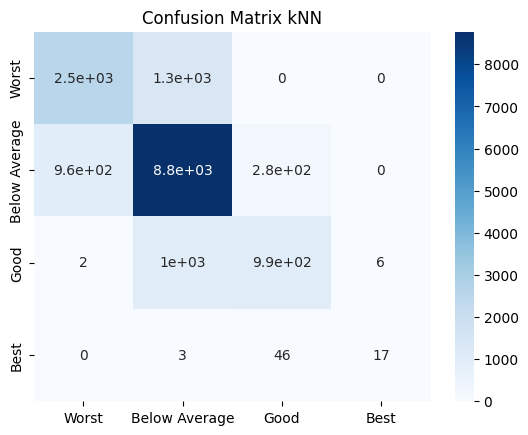

In [5]:
x = data[['Processor_Speed_GHz', 'RAM_GB', 'Storage_GB', 'Battery_mAh', 'Display_Tech', 'Connectivity', 'Camera_Score', 'Update_Support_Years', 'Security_Updates_Per_Year', 'Brand_Score', 'Release_Year', 'Initial_Price_USD', 'Customer_Rating']]
y = data['Obsolescence_Category']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

from sklearn.neighbors import KNeighborsClassifier
model1 = KNeighborsClassifier(n_neighbors = 5)
model1.fit(x_train, y_train)
y_pred = model1.predict(x_test)


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy = {acc}")


cm = confusion_matrix(y_test, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot = True, cmap = 'Blues', xticklabels = ['Worst', 'Below Average', 'Good', 'Best'], yticklabels = ['Worst', 'Below Average', 'Good', 'Best'])
plt.title("Confusion Matrix kNN")
plt.show()

SVM

Accuracy = 0.833125


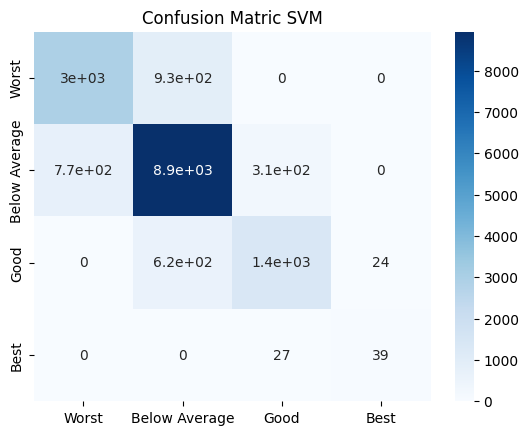

In [6]:
x = data[['Processor_Speed_GHz', 'RAM_GB', 'Storage_GB', 'Battery_mAh', 'Display_Tech', 'Connectivity', 'Camera_Score', 'Update_Support_Years', 'Security_Updates_Per_Year', 'Brand_Score', 'Release_Year', 'Initial_Price_USD', 'Customer_Rating']]
y = data['Obsolescence_Category']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

from sklearn.svm import SVC
model2 = SVC(kernel = 'poly')
model2.fit(x_train, y_train)
y_pred = model2.predict(x_test)

from sklearn.metrics import accuracy_score, confusion_matrix
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy = {acc}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, cmap = 'Blues', xticklabels = ['Worst', 'Below Average', 'Good', 'Best'], yticklabels = ['Worst', 'Below Average', 'Good', 'Best'])
plt.title("Confusion Matric SVM")
plt.show()

Decision Tree

Accuracy =  0.64925


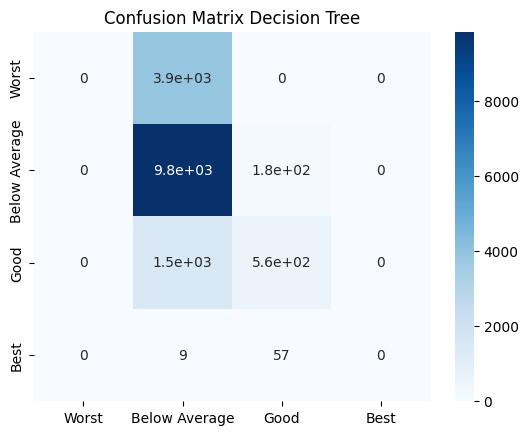

In [7]:
from sklearn.tree import DecisionTreeClassifier
x = data[['Processor_Speed_GHz', 'RAM_GB', 'Storage_GB', 'Battery_mAh', 'Display_Tech', 'Connectivity', 'Camera_Score', 'Update_Support_Years', 'Security_Updates_Per_Year', 'Brand_Score', 'Release_Year', 'Initial_Price_USD', 'Customer_Rating']]
y = data['Obsolescence_Category']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

model3 = DecisionTreeClassifier(criterion = 'entropy', max_depth = 3, min_samples_split = 2, random_state = 42)
model3.fit(x_train, y_train)
y_pred = model3.predict(x_test)

from sklearn import metrics
acc = metrics.accuracy_score(y_test, y_pred)
print("Accuracy = ",acc)

cm = metrics.confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot = True, cmap = 'Blues', xticklabels = ['Worst', 'Below Average', 'Good', 'Best'], yticklabels = ['Worst', 'Below Average', 'Good', 'Best'])
plt.title("Confusion Matrix Decision Tree")
plt.show()

Random Forest

Accuracy = 0.80225


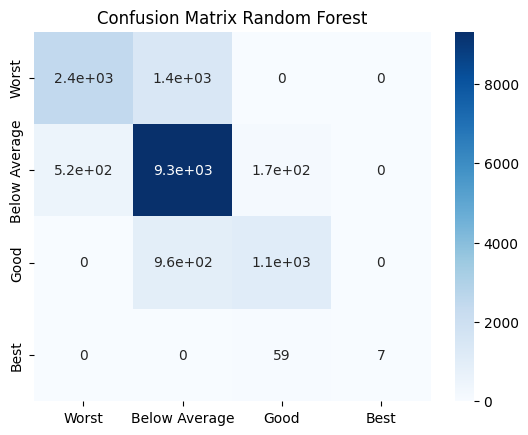

In [8]:
from sklearn.ensemble import RandomForestClassifier
x = data[['Processor_Speed_GHz', 'RAM_GB', 'Storage_GB', 'Battery_mAh', 'Display_Tech', 'Connectivity', 'Camera_Score', 'Update_Support_Years', 'Security_Updates_Per_Year', 'Brand_Score', 'Release_Year', 'Initial_Price_USD', 'Customer_Rating']]
y = data['Obsolescence_Category']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

model4 = RandomForestClassifier(n_estimators = 200, random_state = 42)
model4.fit(x_train, y_train)
y_pred = model4.predict(x_test)

from sklearn.metrics import accuracy_score, confusion_matrix
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy = {acc}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, cmap = 'Blues', xticklabels = ['Worst', 'Below Average', 'Good', 'Best'], yticklabels = ['Worst', 'Below Average', 'Good', 'Best'])
plt.title("Confusion Matrix Random Forest")
plt.show()

In [13]:
import joblib 

joblib.dump(model2, "../Model/best_model_SVM.pkl")

['../Model/best_model_SVM.pkl']